In [1]:
##cleaning data using python lib panda 
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
uber_df=pd.read_csv('UberDataset.csv')

In [3]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
uber_df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [5]:
uber_df.drop(uber_df.index[-1],inplace=True )

In [6]:
uber_df.shape

(1155, 7)

In [7]:
uber_df.info()## it is a method it print the information it is qucik summary 
##give index information, coloumn information 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [8]:
uber_df.size

8085

In [9]:
list(uber_df.columns)

['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES', 'PURPOSE']

In [10]:
uber_df.dtypes

START_DATE     object
END_DATE       object
CATEGORY       object
START          object
STOP           object
MILES         float64
PURPOSE        object
dtype: object

In [11]:
uber_df.select_dtypes(include=['object'])

,START_DATE,END_DATE,CATEGORY,START,STOP,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,Customer Visit
...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,Temporary Site


In [12]:
uber_df.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [13]:
uber_df['PURPOSE'].fillna('NOT', inplace=True)

C:\Users\hai\AppData\Local\Temp\ipykernel_5208\2215468107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uber_df['PURPOSE'].fillna('NOT', inplace=True)


In [14]:
##data prepossing
uber_df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [15]:
uber_df[uber_df.duplicated()]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
492,6/28/2016 23:34,6/28/2016 23:59,Business,Durham,Cary,9.9,Meeting


In [16]:
uber_df.drop_duplicates(inplace=True)

In [17]:
uber_df.describe()

,MILES
count,1154.000000
mean,10.567418
std,21.588452
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,310.300000


In [18]:
uber_df.describe(include=['object'])

,START_DATE,END_DATE,CATEGORY,START,STOP,PURPOSE
count,1154,1154,1154,1154,1154,1154
unique,1154,1154,2,177,188,11
top,01-01-2016 21:11,01-01-2016 21:17,Business,Cary,Cary,NOT
freq,1,1,1077,201,202,502


In [19]:
uber_df['START_DATE']=pd.to_datetime(uber_df['START_DATE'],errors='coerce')

In [20]:
uber_df['END_DATE']=pd.to_datetime(uber_df['END_DATE'],errors='coerce')

In [21]:
from datetime import datetime
uber_df['date']=pd.DatetimeIndex(uber_df['START_DATE']).date
uber_df['time']=pd.DatetimeIndex(uber_df['START_DATE']).hour

In [22]:
uber_df['day-night']=pd.cut(x=uber_df['time'], bins=[0,10,15,19,24], labels=['Morning','Afternoon','Evening','Night'])

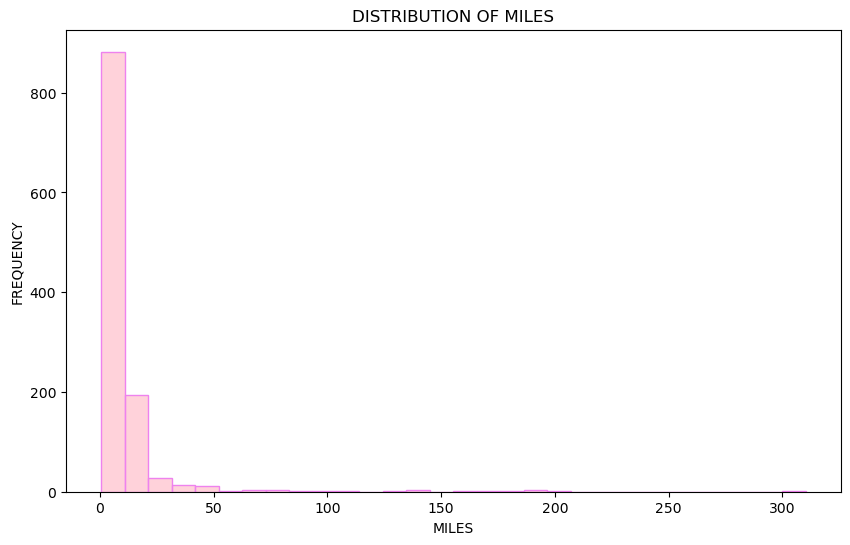

In [23]:
##data visualization 
plt.figure(figsize=(10,6))
sns.histplot(uber_df['MILES'] ,bins=30,color='pink',edgecolor='violet',alpha=0.7)##ALPHA-TRANSPERENCY LEVEL
plt.xlabel('MILES')
plt.ylabel('FREQUENCY')
plt.title('DISTRIBUTION OF MILES')
plt.show()

In [24]:
print(uber_df['START'].nunique())

177


In [25]:
uber_df['STOP'].nunique()

188

In [26]:
uber_df['START'].value_counts().head(10)

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Lahore               36
Durham               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

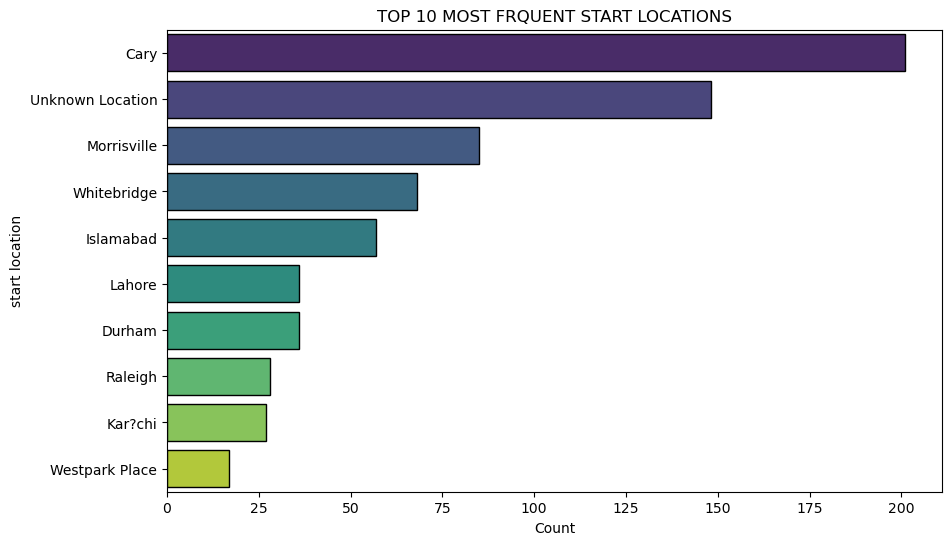

In [27]:

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,6))

sns.countplot(y='START',order=pd.value_counts(uber_df['START']).iloc[:10].index,
               data= uber_df,
               palette='viridis',
               edgecolor='black')
plt.xlabel('Count')
plt.ylabel('start location')
plt.title('TOP 10 MOST FRQUENT START LOCATIONS')
plt.show()

In [28]:
obj =(uber_df.dtypes =='object')
object_cols=list(obj[obj].index)
unique_values={}
for col in object_cols:
    unique_values[col]=uber_df[col].unique().size
unique_values

{'CATEGORY': 2, 'START': 177, 'STOP': 188, 'PURPOSE': 11, 'date': 115}

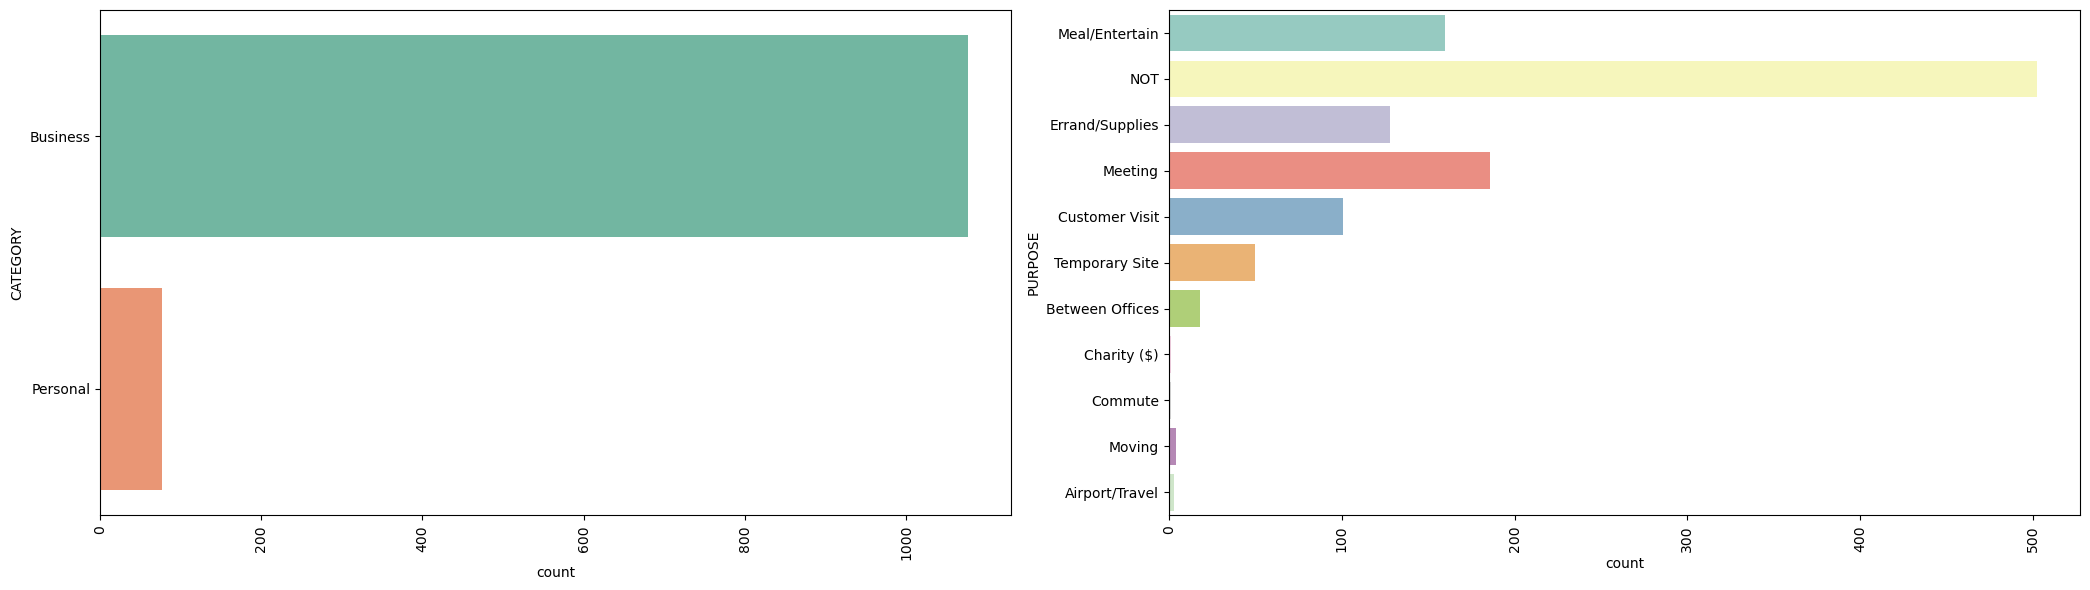

In [29]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(21,6))
plt.subplot(1,2,1)
sns.countplot(uber_df['CATEGORY'],palette='Set2')
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(uber_df['PURPOSE'],palette='Set3')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


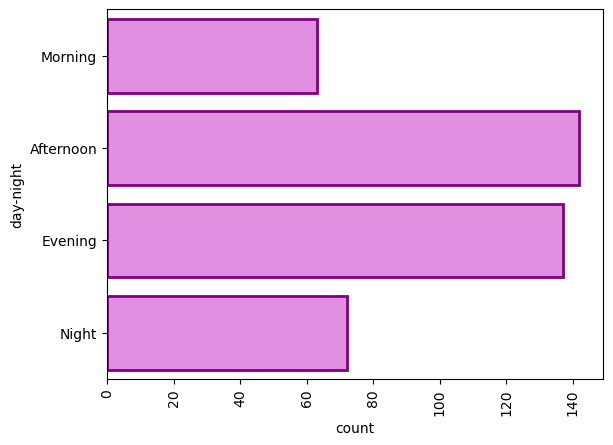

In [30]:
sns.countplot(uber_df['day-night'],color='violet',edgecolor='purple',linewidth=2)
plt.xticks(rotation=90)
plt.show()

In [31]:
##warnings.filterwarnings('ignore',category=DeprecationWarnings)
##warnings.fliterwarnings('error', category=DeprecationWarnings)

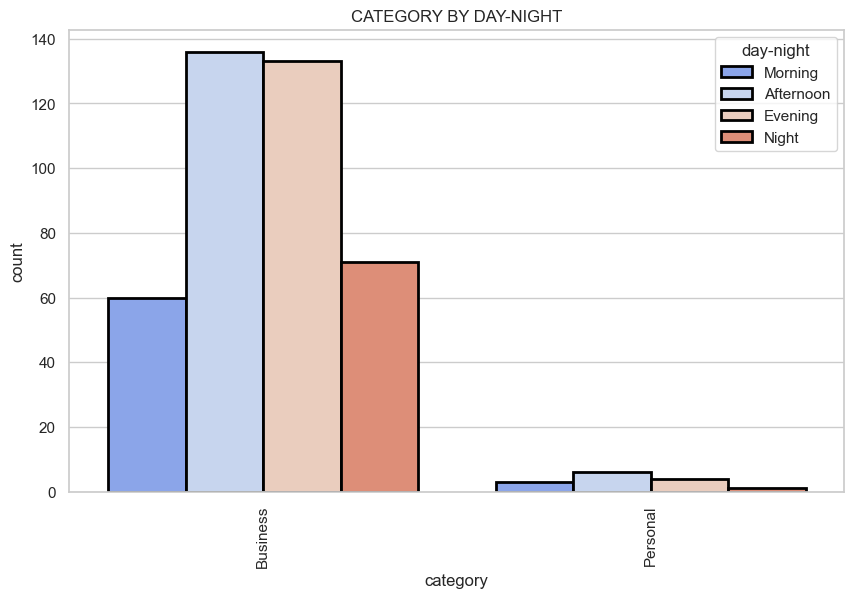

In [97]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='CATEGORY',hue='day-night', palette='coolwarm',edgecolor='black',linewidth=2)
plt.xticks(rotation=90)
plt.title('CATEGORY BY DAY-NIGHT')
plt.xlabel('category')
plt.ylabel('count')
plt.show()

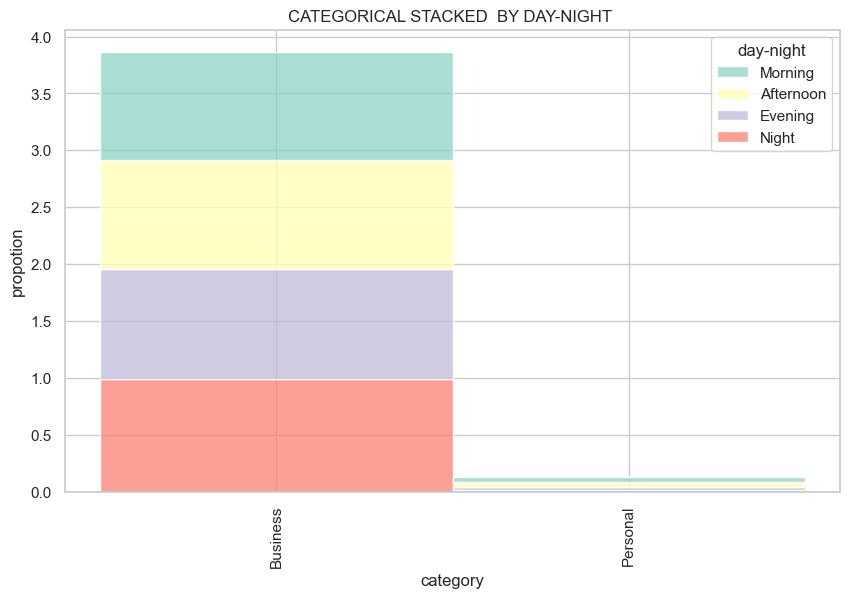

In [98]:
plt.figure(figsize=(10,6))
sns.histplot(data=uber_df,x='CATEGORY',hue='day-night', stat='probability',common_norm= False, multiple='stack',palette='Set3',edgecolor='black')
plt.xticks(rotation=90)
plt.title('CATEGORICAL STACKED  BY DAY-NIGHT ')
plt.xlabel('category')
plt.ylabel('propotion')
plt.show()

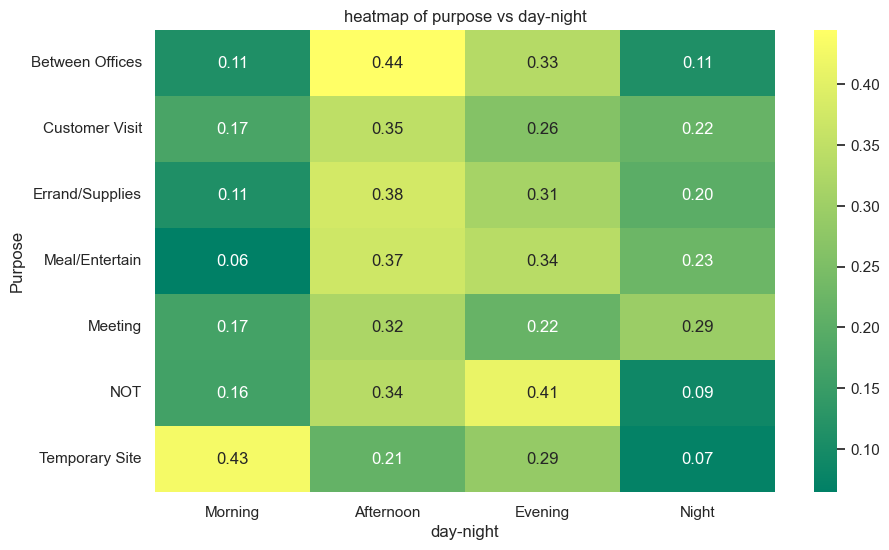

In [99]:
##using heatmap we can find the amt of corelation
plt.figure(figsize=(10,6))
heatmap_data=uber_df.groupby(['PURPOSE','day-night']).size().unstack()
heatmap_data=heatmap_data.div(heatmap_data.sum(axis=1),axis=0)

sns.heatmap(heatmap_data,annot=True,cmap='summer',fmt='.2f')##annot will enter the values annot=false does not enter anyvalue,cmap- is colour of the map,cmap='YlGnBu' ,fmd is format of the map 
plt.title('heatmap of purpose vs day-night')
plt.xlabel('day-night')
plt.ylabel('Purpose')
plt.show()
## heatmap plot the density or intensity of corelation of two different variables 

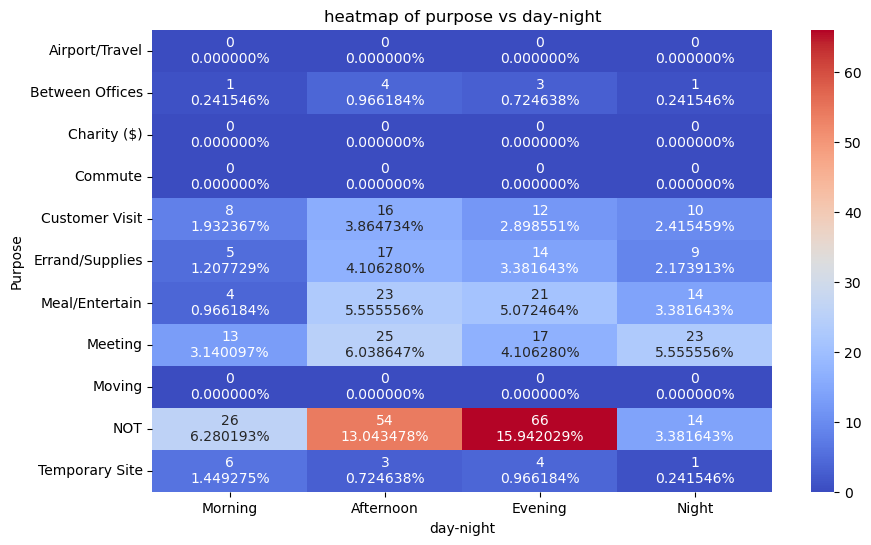

In [35]:
plt.figure(figsize=(10,6))
heatmap_data=uber_df.groupby(['PURPOSE','day-night']).size().unstack()
total=heatmap_data.sum().sum()
sns.heatmap(heatmap_data,annot=heatmap_data.applymap(lambda x:f'{x}\n{x/total:%}'),cmap='coolwarm',fmt='s')##annot will enter the values annot=false does not enter anyvalue,cmap- is colour of the map,cmap='YlGnBu' ,fmd is format of the map 
plt.title('heatmap of purpose vs day-night')
plt.xlabel('day-night')
plt.ylabel('Purpose')
plt.show()

<Figure size 800x800 with 0 Axes>

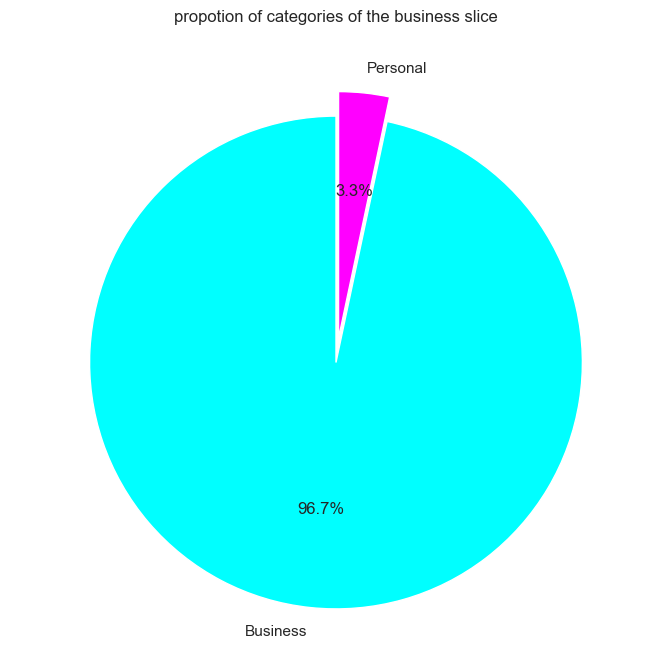

In [100]:
plt.figure(figsize=(8,8))
##explode=[0.1 if cat =='Business' else 0 for cat in uber_df['CATEGORY'].value_counts().index]## unique to show the bussines part so 10% the business will explode, to show the part alone 
####plt.ylabel(' ')
##plt.show()
plt.figure(figsize=(8,8))
# Uncommented the explode definition - creates a list that explodes 'Business' category by 10%
explode=[0.1 if cat =='Business' else 0 for cat in uber_df['CATEGORY'].value_counts().index]
uber_df['CATEGORY'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,explode=explode,cmap='cool')
plt.title('propotion of categories of the business slice ')
plt.ylabel(' ')
plt.show()

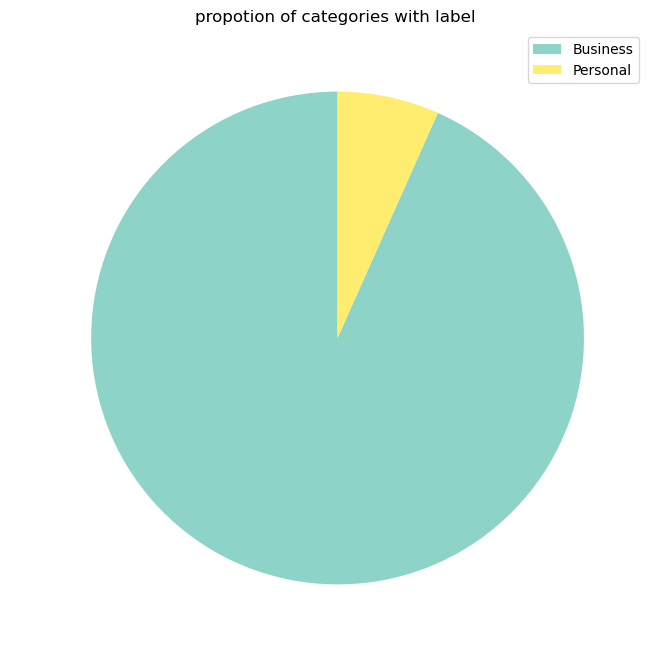

In [37]:
plt.figure(figsize=(8,8))
 
uber_df['CATEGORY'].value_counts().plot.pie(autopct= None ,startangle=90,cmap='Set3',labels=None)
plt.title('propotion of categories with label ')
plt.ylabel(' ')
plt.legend(labels=uber_df['CATEGORY'].value_counts().index,loc='upper right')
plt.show()

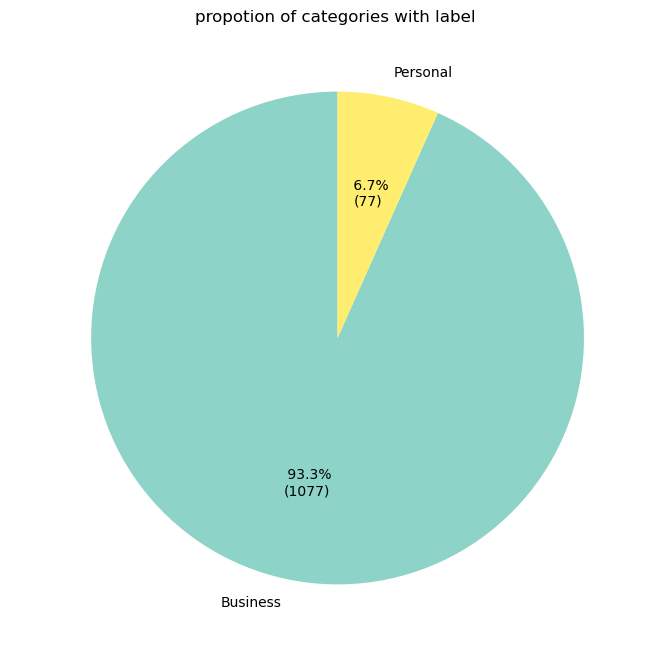

In [38]:
plt.figure(figsize=(8,8))
def autopct_with_counts(pct,values):
    total=sum(values)
    absolute=int(pct/100*total)
    return f'{pct: .1f}%\n({absolute})'

uber_df['CATEGORY'].value_counts().plot.pie(autopct= lambda pct:autopct_with_counts(pct,uber_df['CATEGORY'].value_counts()) ,startangle=90,cmap='Set3')
plt.title('propotion of categories with label ')
plt.ylabel(' ')
plt.show()

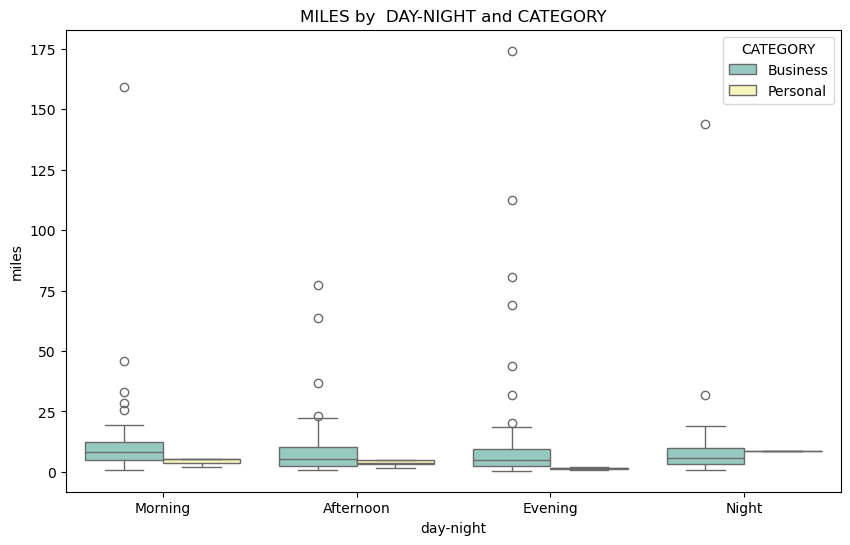

In [39]:
##DISTRIBUTION OF MILES OF ALONG DAY AND NIGHT BOXPLOT WE CAN CREATE BOX PLOT 
#FOR NUMERICAL AND CATGORICAL DATA OR VALUE it give statiscial infromation like
##mean median 
## HUE = SHOW DIFFERENCE ACROSS VARIOUS CATEGORY TRY THIS CODE WITHOUT HUE 
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='day-night',y='MILES',hue='CATEGORY',palette='Set3')
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

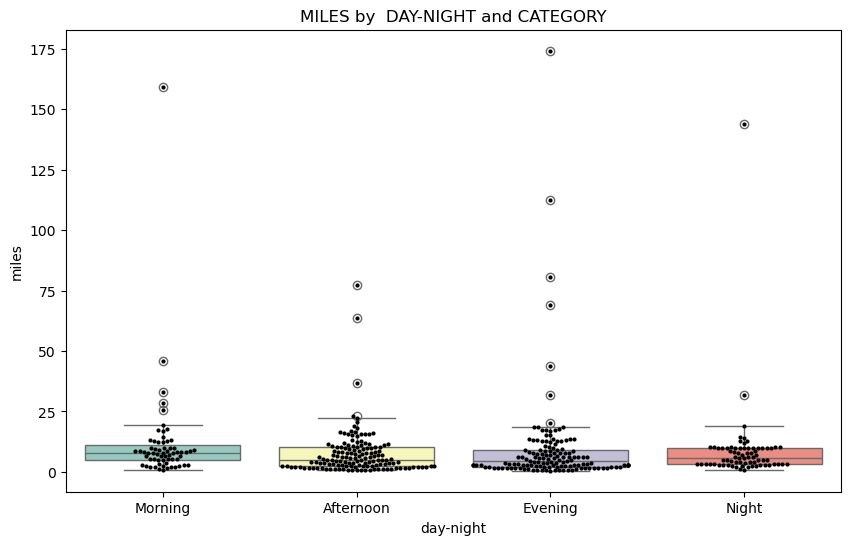

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='day-night',y='MILES',palette='Set3')
sns.swarmplot(data=uber_df,x='day-night',y='MILES',color='black',size=3 )
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

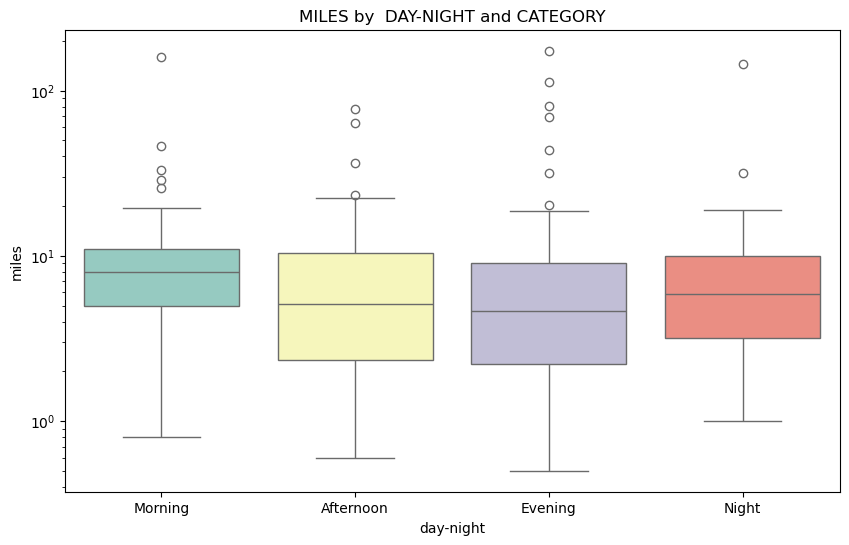

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='day-night',y='MILES',palette='Set3')
plt.yscale('log')
##log:
##make the boxplot visible so we can visulaize esily and we can find the outlier ,
##when there are more category and
##outlier when the box plot is not that mush visible we use this log  
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

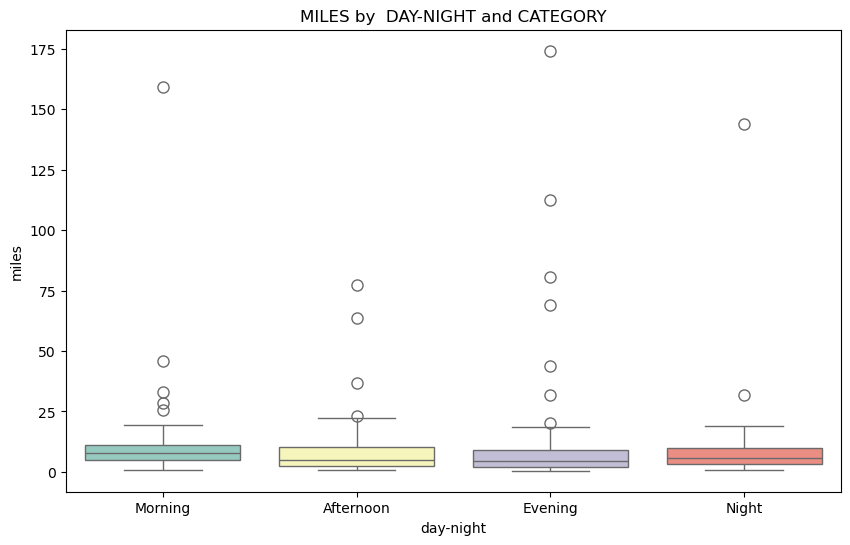

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=uber_df,x='day-night',y='MILES',palette='Set3',showfliers=True , fliersize=8)
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

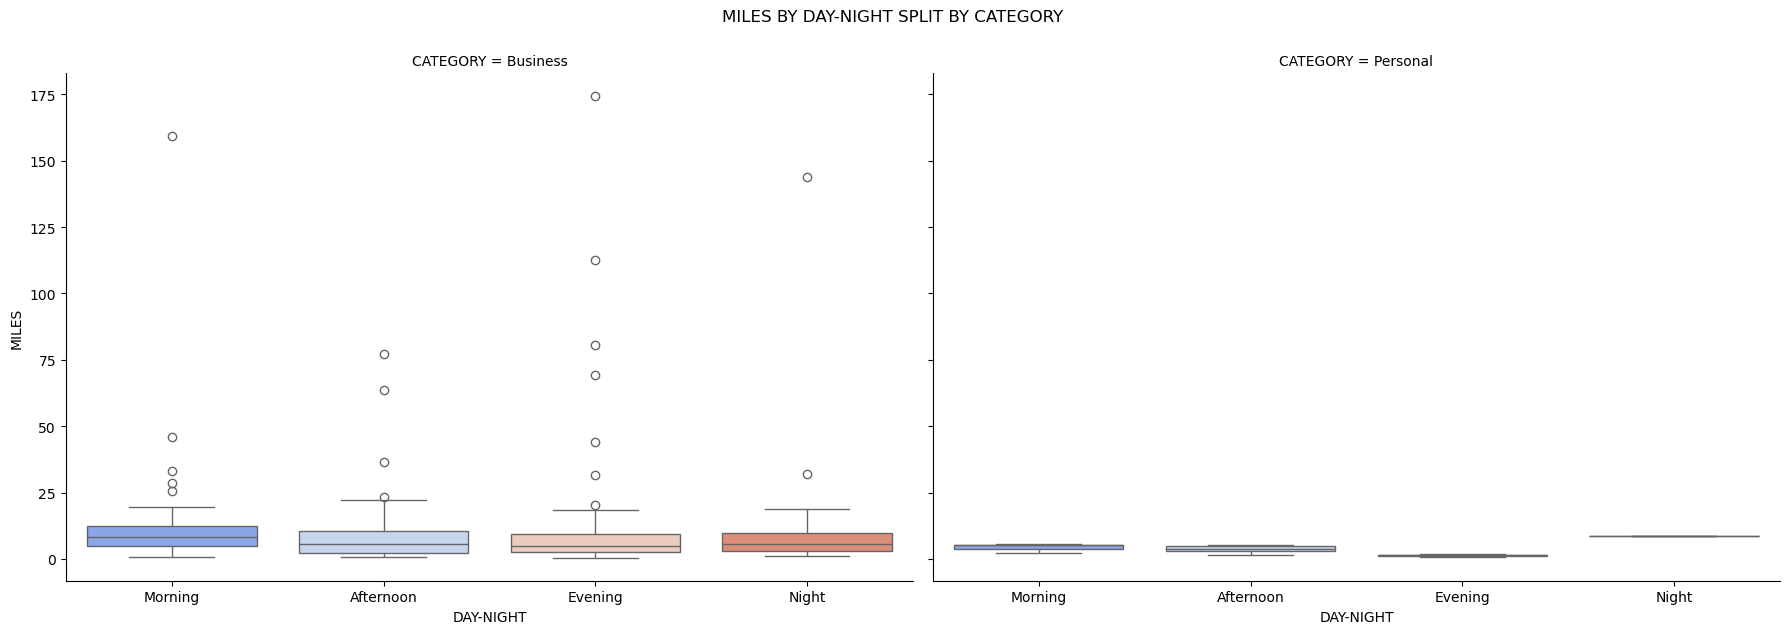

In [43]:
g=sns.FacetGrid(uber_df,col='CATEGORY',height=6,aspect=1.5)
g.map(sns.boxplot,'day-night','MILES',palette='coolwarm')
g.set_axis_labels('DAY-NIGHT','MILES')
g.fig.suptitle('MILES BY DAY-NIGHT SPLIT BY CATEGORY ',y=1.05)

plt.show()

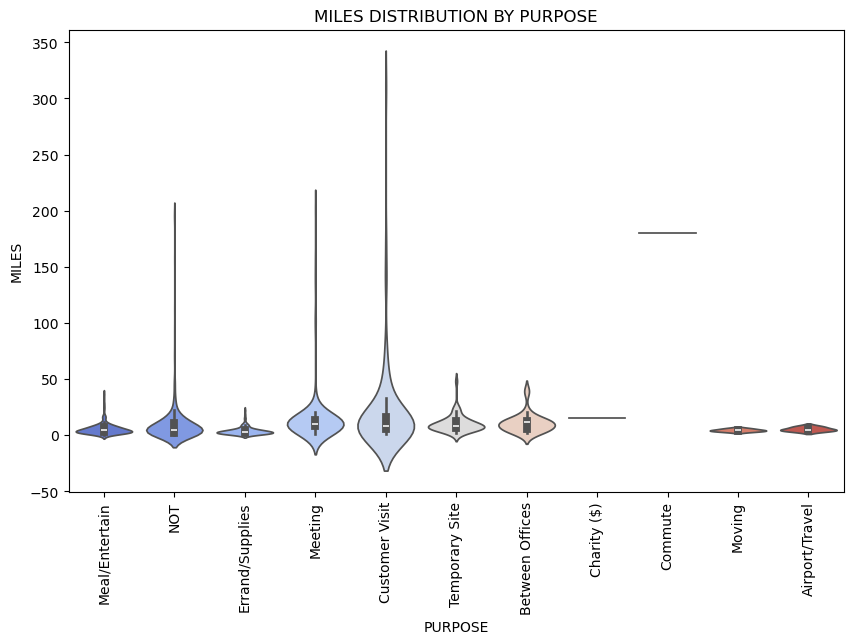

In [44]:
##violin plot shows the numeric distribution along many category 
## it is combination of boxplot and kernal density estimation
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df, x='PURPOSE',y='MILES',palette='coolwarm')
plt.xticks(rotation=90)
plt.title('MILES DISTRIBUTION BY PURPOSE')
plt.show()

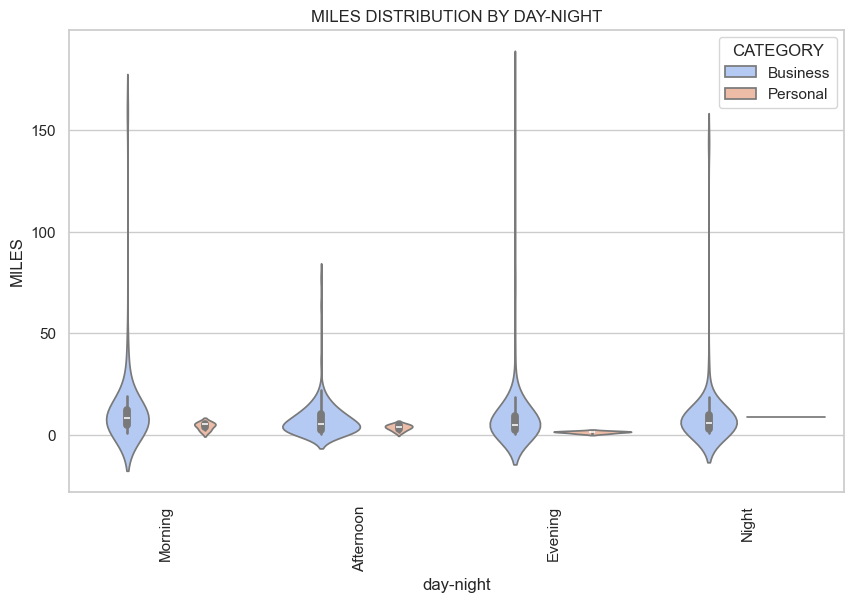

In [45]:
## a small chages in violin plot
## TRY THIS CODE WITH HUE AND WIHTOUT HUE 
sns.set(style='whitegrid')##-change the background into white 
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df, x='day-night',y='MILES',hue='CATEGORY',palette='coolwarm') 
##IN PALETTE SET3 AND BLUES ARE SAME COLOUR 
plt.xticks(rotation=90)
plt.title('MILES DISTRIBUTION BY DAY-NIGHT')
plt.show()

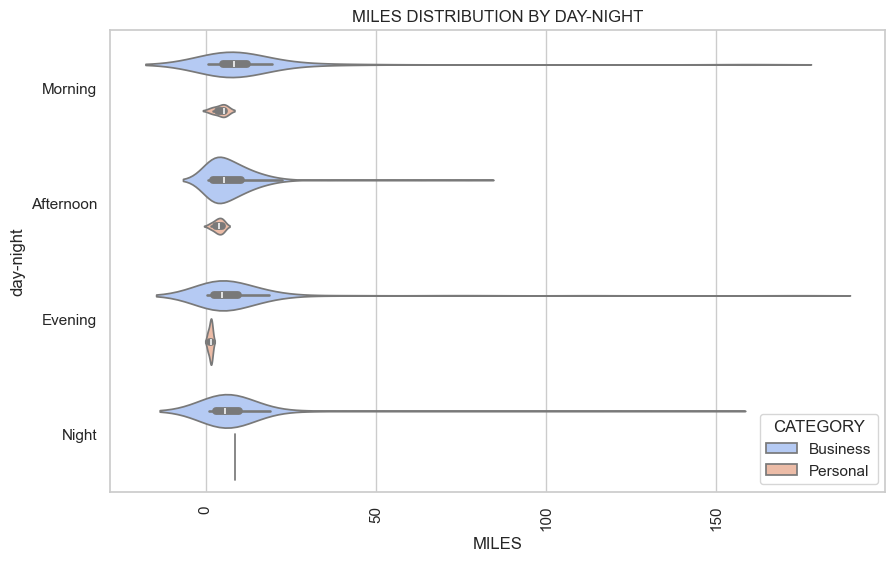

In [46]:
## TO SHOW THE VILOIN PLOT HORIZONTAL CHANGE THE X AXIS AND Y AXIS
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df, y='day-night',x='MILES',hue='CATEGORY',palette='coolwarm') 
plt.xticks(rotation=90)
plt.title('MILES DISTRIBUTION BY DAY-NIGHT')
plt.show()

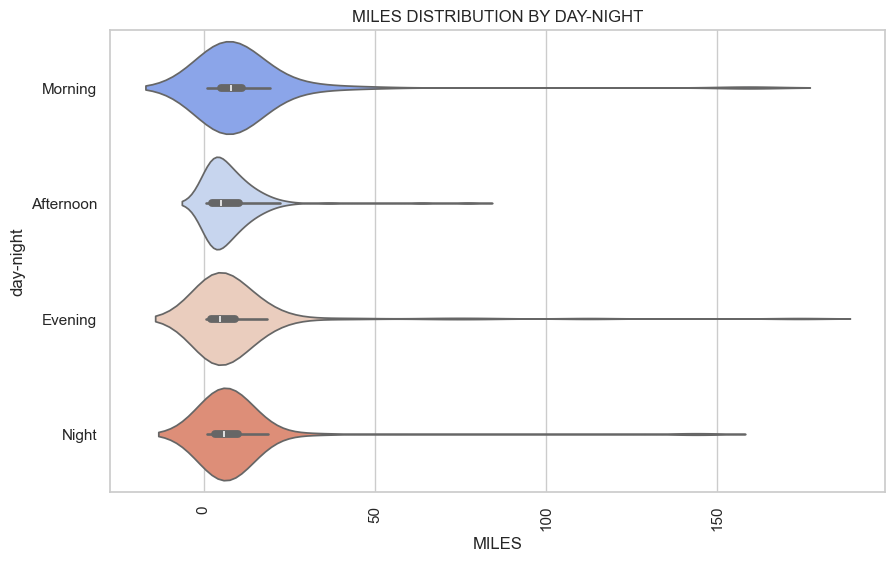

In [47]:
## to create a boxplot in violin plot a muliple plot \
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df, y='day-night',x='MILES',inner='box',palette='coolwarm') 
plt.xticks(rotation=90)
plt.title('MILES DISTRIBUTION BY DAY-NIGHT')
plt.show()

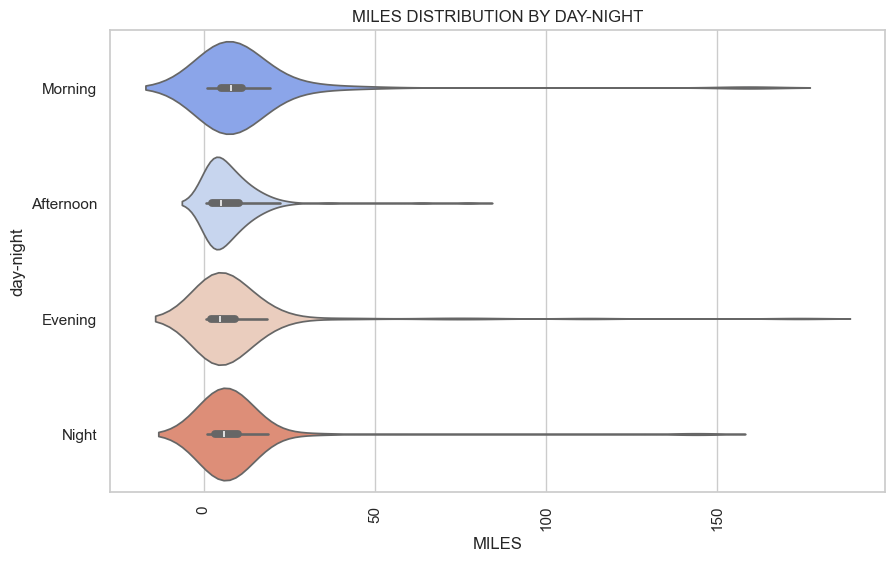

In [48]:
## we here use  scale which helps us to bring  all violin plot in same scale width 
#So we can compare easily we can give " scale = area --> it create a viloin plot that
## scales area with the plot "

sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.violinplot(data=uber_df, y='day-night',x='MILES',scale='width',palette='coolwarm') 
plt.xticks(rotation=90)
plt.title('MILES DISTRIBUTION BY DAY-NIGHT')
plt.show()

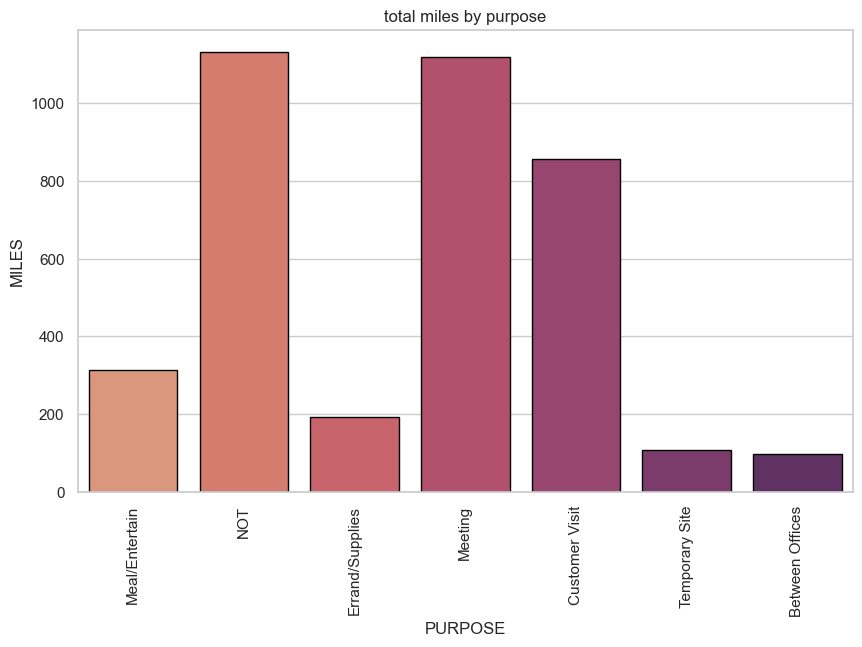

In [101]:
##barplot
##to aggrecate we use 'estimator'
## to avoid overlap we use 'xticks' try different value in xticks ,so 90 is best 
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, ci=None, palette='flare',edgecolor='black')
plt.xticks(rotation=90)
plt.title('total miles by purpose')
plt.show()

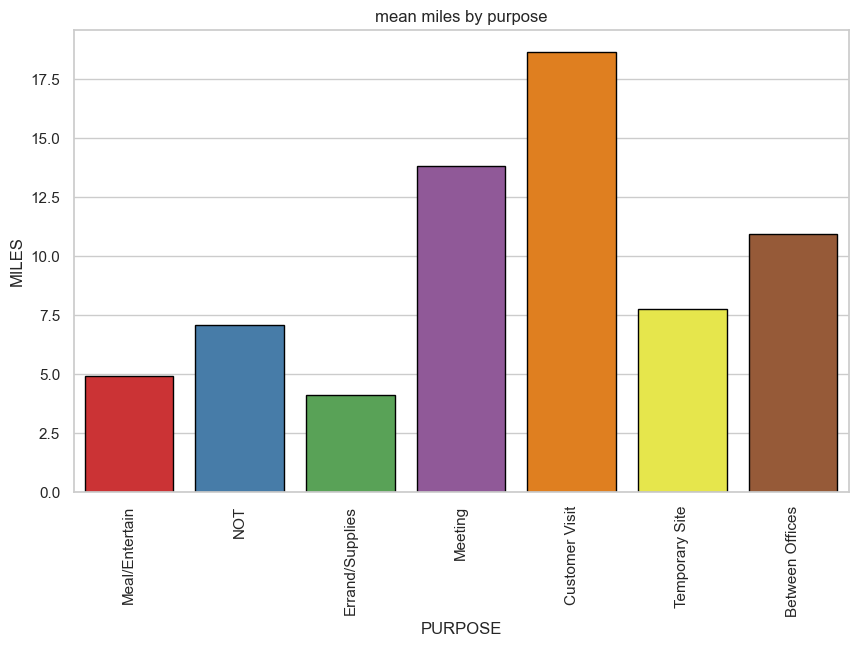

In [102]:
### we can change the aggregation in the barplot as follows 
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=np.mean, ci=None, palette='Set1',edgecolor='black')
plt.xticks(rotation=90)
plt.title('mean miles by purpose')
plt.show()

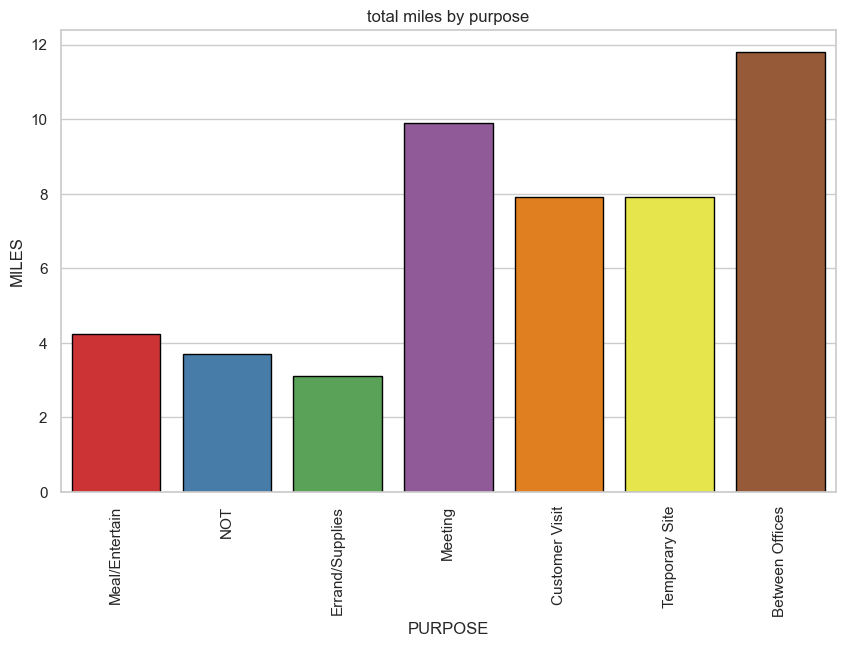

In [103]:
## here we use aggreation median
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=np.median, ci=None, palette='Set1',edgecolor='black')
plt.xticks(rotation=90)
plt.title('total miles by purpose')
plt.show()

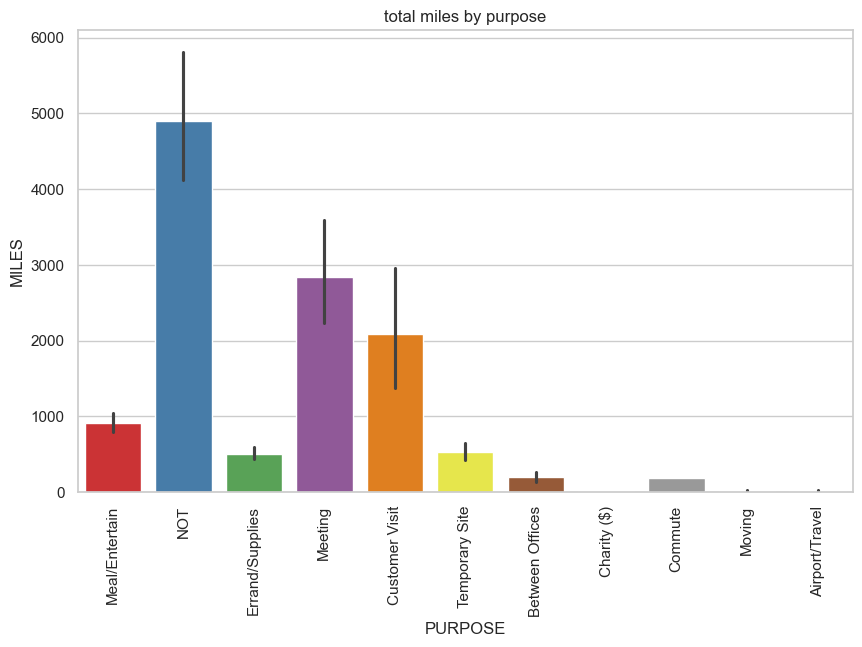

In [52]:
## here we rmeove ci=none 
## ** therefore it shows confidential interval**
##A confidence interval (CI) in data science is a range of values, 
##calculated from sample data, that is likely to contain an unknown population parameter 
##(such as a mean or proportion) with a specified level of confidence (e.g., 95%). It quantifies uncertainty by providing a range rather than a single point estimat
## WE CAN DEFINE CONFIDENTIAL INTERVAL by giving various percentage value instead of none ..

plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, palette='Set1')
plt.xticks(rotation=90)
plt.title('total miles by purpose')
plt.show()

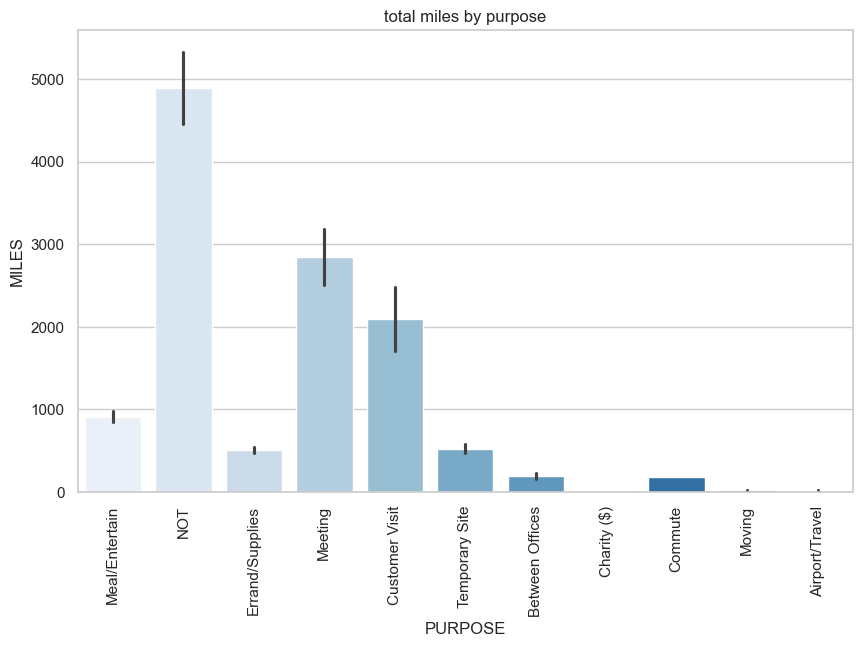

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum,ci=68, palette='Blues')
plt.xticks(rotation=90)
plt.title('total miles by purpose')
plt.show()

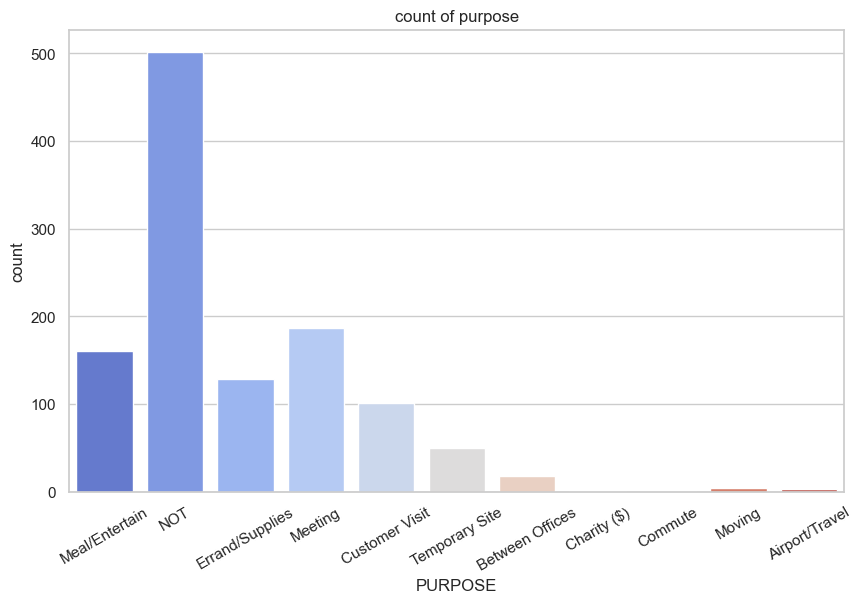

In [54]:
##COUNTPLOT
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='PURPOSE' ,palette='coolwarm')
plt.xticks(rotation=30)
plt.title('count of purpose')
plt.show()

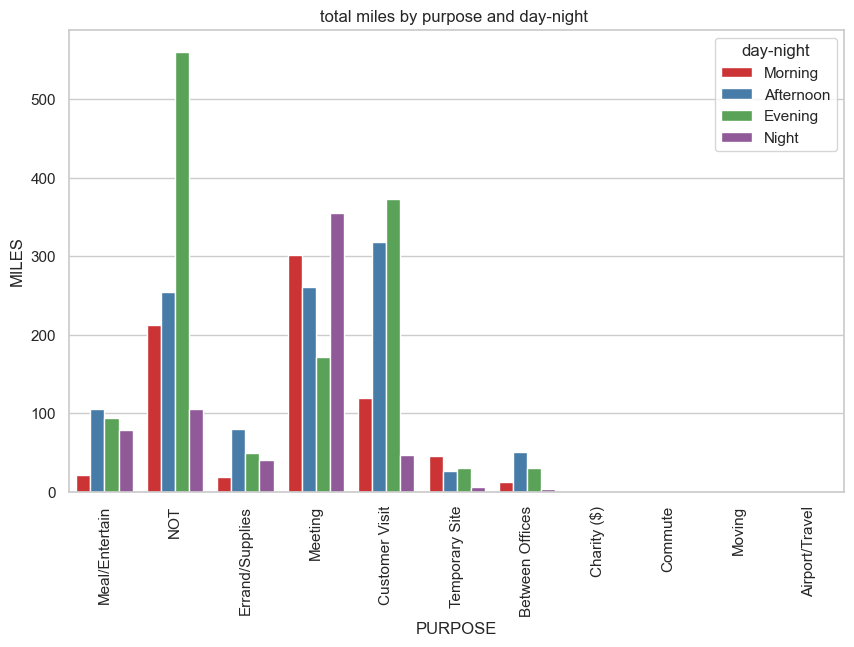

In [55]:
##with recepect to day-night each category how much travelled is shown in the bar plot 

plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES',hue='day-night', estimator=sum, ci=None, palette='Set1')
plt.xticks(rotation=90)
plt.title('total miles by purpose and day-night ')
plt.show()

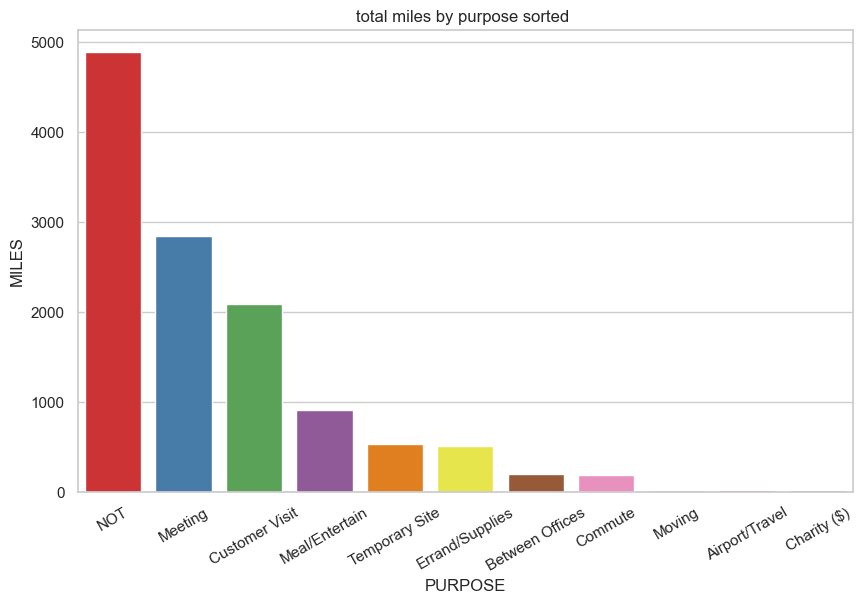

In [56]:
###TO SORT THE BARCHART in ascending order 
plt.figure(figsize=(10,6))
order=uber_df.groupby('PURPOSE')['MILES'].sum().sort_values(ascending=False).index
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, ci=None, palette='Set1',order=order)
plt.xticks(rotation=30)
plt.title('total miles by purpose sorted ')
plt.show()

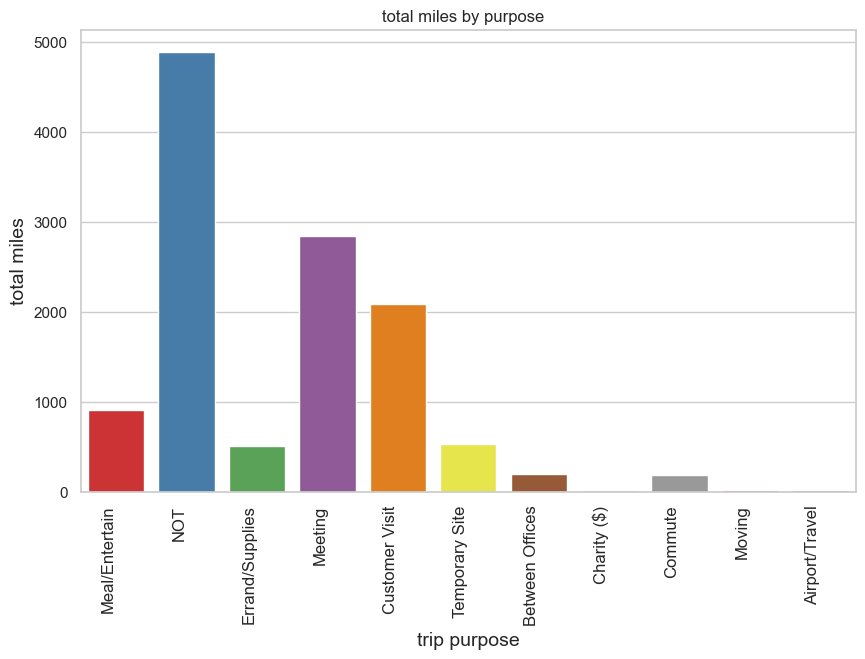

In [57]:
## here we are going to chage the font size 
## we can cutomize the chart we can use what font wanted 

plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, ci=None, palette='Set1')
plt.xticks(rotation=90,ha='right',fontsize=12)
plt.xlabel('trip purpose',fontsize=14)
plt.ylabel('total miles',fontsize=14)
plt.title('total miles by purpose  ')
plt.show()

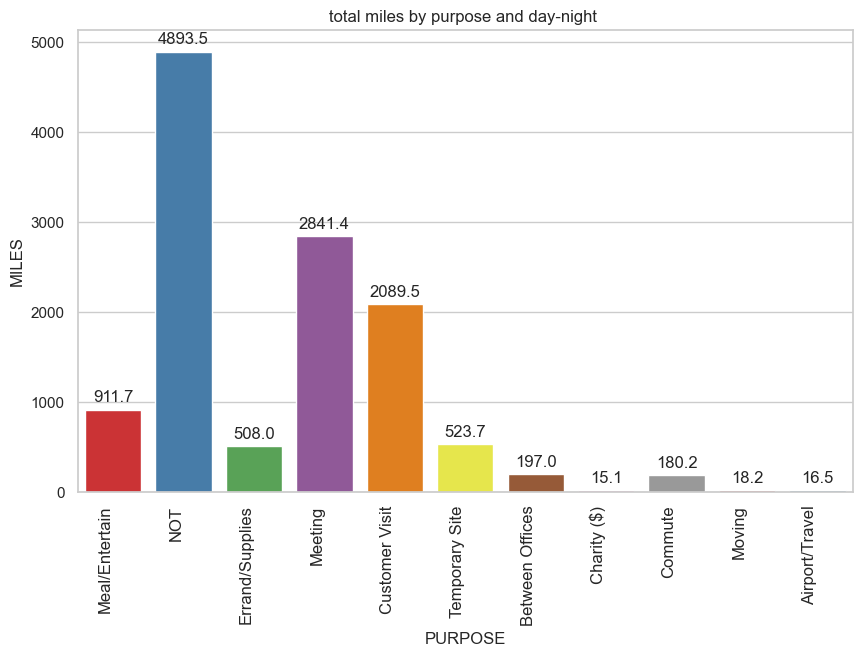

In [58]:
##in barplot is made up of patches (rectangle object)
##-->here we use pathes to iterate throught each bar plot individually to highlight 
##-->annotate is a function in python here we gave sum value which help to display that in barplot
##-->here we gave p.get_height():.1f if values are 5.3814 it will round off to one decimal point 
##-->get_height() it will get height of tha bar and dispaly it 
##-->get_x() it will get the value of x
##-->get_width() it will take the width value and place it get height soin bar center value will display
##-->ha,va help the text to alligh center and xytext it helps to display the value clearly to avoid overlap with barplot
##-->(0,9) don't do anything in x in y,seperate  9 points 
##-->textcoords=offsetpoints it will loop each and every bar form that bar,it will offset the points and display so it increase the readability


plt.figure(figsize=(10,6))
ax=sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, ci=None, palette='Set1')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',(p.get_x()+p.get_width()/2,p.get_height()),
    ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.xticks(rotation=90,ha ='right',fontsize=12 )
plt.title('total miles by purpose and day-night ')
plt.show()

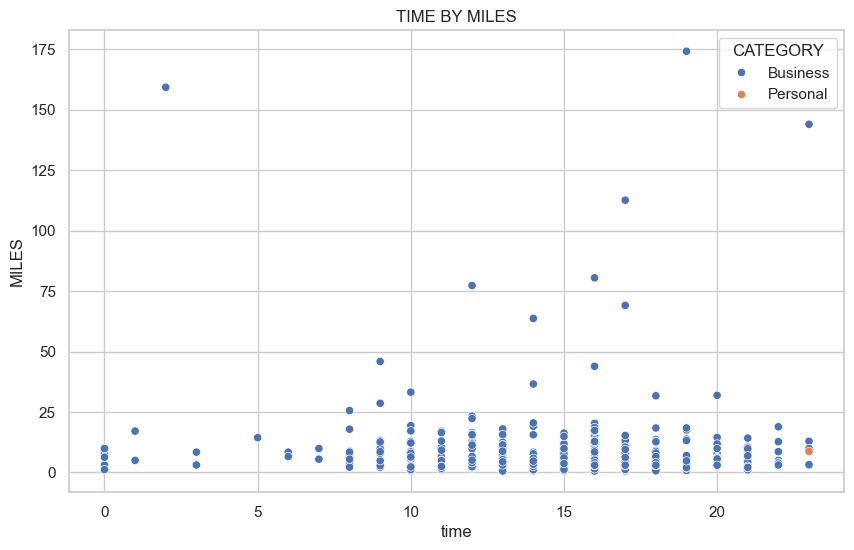

In [59]:
###SCATTER PLOT (examine the relationship)
##-->fundamental tool which shows relationship between two numerical variables
##-->it helps to find pattterns and corelation
##-->it helps find the if the value of x axis vary or y axis vary we can find the how it afftect eachother 
##-->each datapoints are the result of two variables it shows the realtionship 
##--> the realtionship between two variables are classtified as 
### ------ :*positive realtionship positive corealtion(x increaces and y also incresess )
###--------* neagtive corealtion(x increses and y decreses and viceversa) and no corealtion(no standard plot)
##--> it helps to find the linearrealtionship and nonlinaer (curved plot)
##--. we can find strong corealtion(tow points are together)and weak corelation(points are scattered)
##--> we can find how the data distributed and patterens and trend 
##---> in clustering we use scatterplot, so that we can find the natural groupings 
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber_df,x='time',y='MILES',hue='CATEGORY')
plt.title("TIME BY MILES")
plt.show()

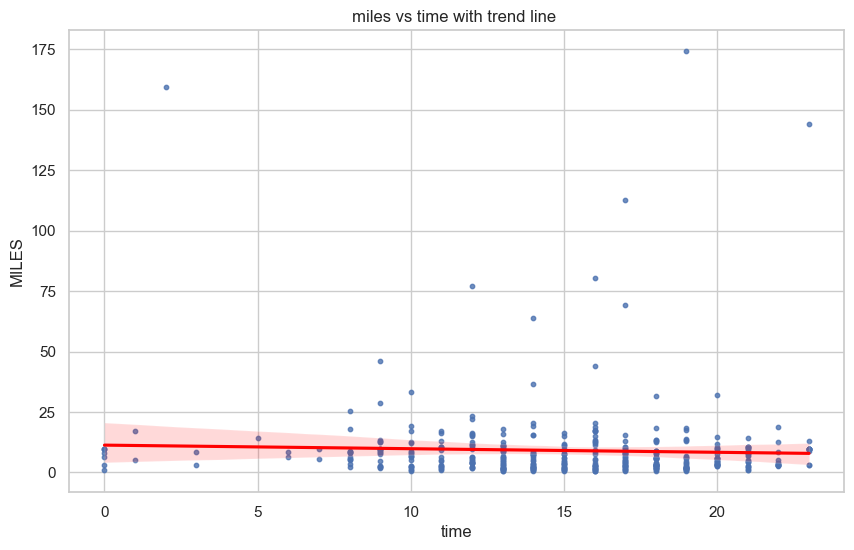

In [60]:
##HERE WE ARE GOING TO SEE HOW WE CAN ADD TREND LINE IN THE PLOT 
plt.figure(figsize=(10,6))
sns.regplot(data=uber_df,x='time',y='MILES', scatter_kws={'s':10},line_kws={'color':'red'})
plt.title("miles vs time with trend line ")
plt.show()


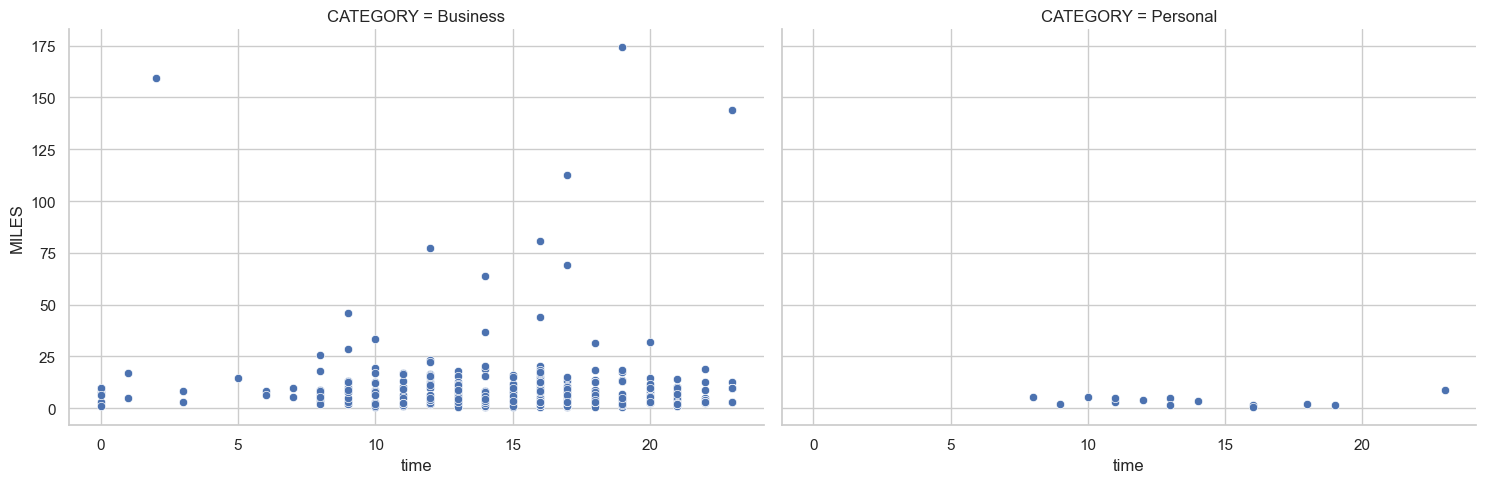

In [61]:
g=sns.FacetGrid(uber_df,col='CATEGORY',height=5,aspect=1.5)
g.map(sns.scatterplot,'time','MILES')
g.add_legend()
plt.show()


In [62]:
uber_df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'date', 'time', 'day-night'],
      dtype='object')

In [64]:
uber_df.drop_duplicates(subset=['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'date', 'time', 'day-night'],keep='first')

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1149,NaT,NaT,Business,Kar?chi,Kar?chi,0.8,Customer Visit,NaT,NaN,NaN
1150,NaT,NaT,Business,Kar?chi,Kar?chi,0.7,Meeting,NaT,NaN,NaN
1151,NaT,NaT,Business,Kar?chi,Unknown Location,3.9,Temporary Site,NaT,NaN,NaN
1153,NaT,NaT,Business,Katunayake,Gampaha,6.4,Temporary Site,NaT,NaN,NaN


In [ ]:
uber_df.drop(columns=['day-night'], inplace=True)

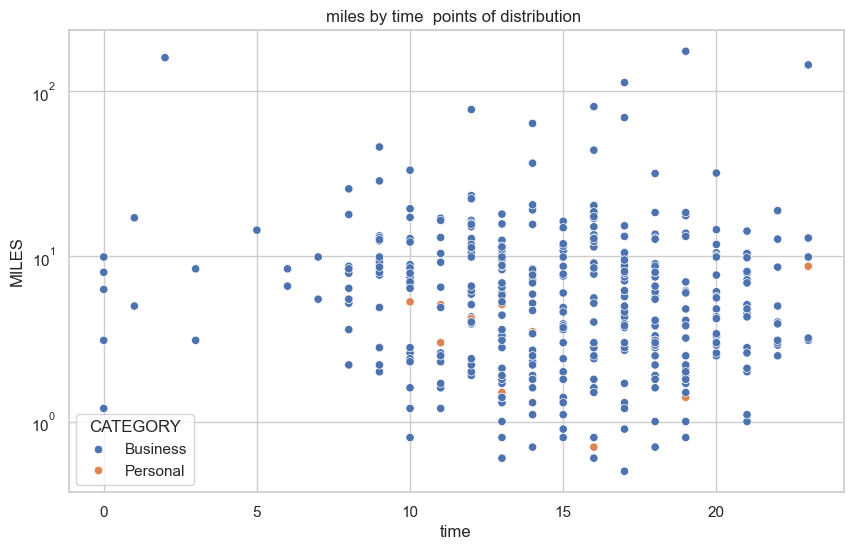

In [65]:
## cutsomizing the plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber_df,x='time',y='MILES',hue='CATEGORY',sizes=(20,200))
plt.yscale('log')
plt.title("miles by time  points of distribution ")
plt.show()

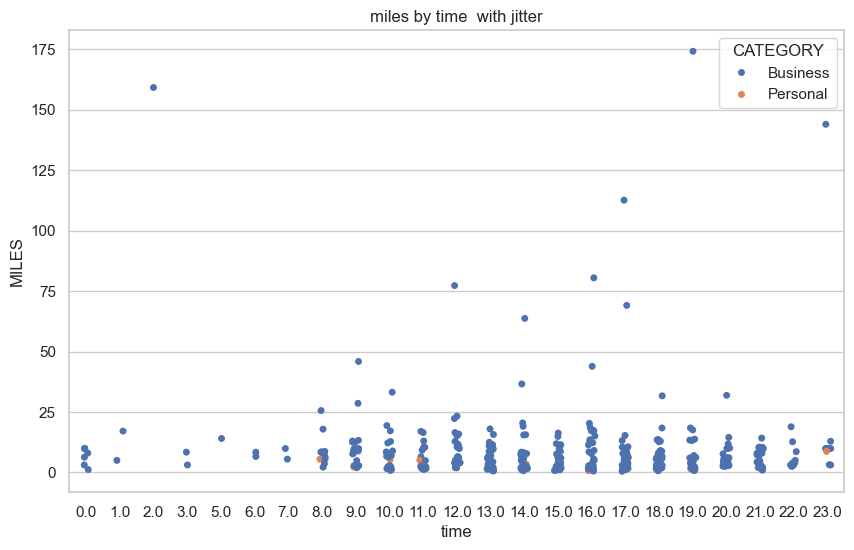

In [66]:
##cutomizing the chart 
##__-->jitter will elonged the plot
plt.figure(figsize=(10,6))
sns.stripplot(data=uber_df,x='time',y='MILES',hue='CATEGORY',jitter=True)
plt.title("miles by time  with jitter")
plt.show()

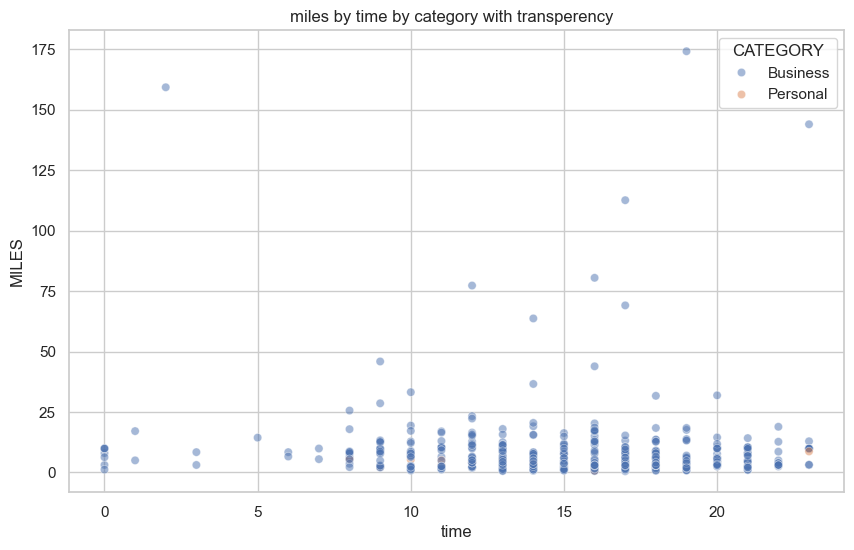

In [67]:
##to imporve the transperencsy we cna modify the more in the plot 
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber_df,x='time',y='MILES',hue='CATEGORY',alpha=0.5)
plt.title("miles by time by category with transperency  ")
plt.show()

In [68]:
##to check the stop and start parameter location are in same \
def round(x):##_-->x is row in panda dataframe 
    if x['START']==x['STOP']:
        return 'yes'
    else:
        return 'no'

In [69]:
uber_df['ROUND_TRIP']=uber_df.apply(round,axis=1)##new coloums result of the function that aplied to the uber_df 


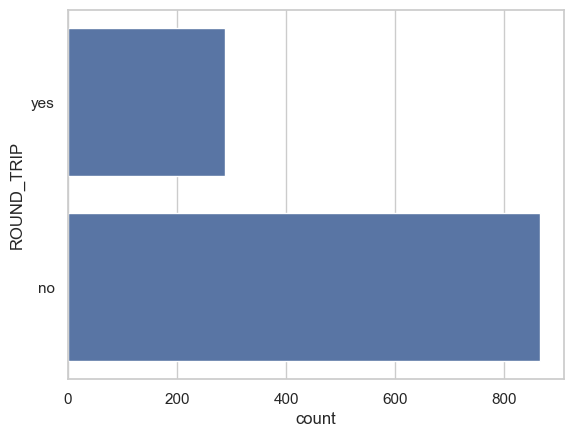

In [70]:
sns.countplot(uber_df['ROUND_TRIP'])##VISULIZATION THE COUNT
plt.show()

In [71]:
uber_df['MONTH']=pd.DatetimeIndex(uber_df['START_DATE']).month

In [72]:
uber_df['MONTH']

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1150    NaN
1151    NaN
1152    NaN
1153    NaN
1154    NaN
Name: MONTH, Length: 1154, dtype: float64

In [73]:
dict = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'July',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

In [74]:
uber_df['MONTH'].map(dict)

0       Jan
1       Jan
2       Jan
3       Jan
4       Jan
       ... 
1150    NaN
1151    NaN
1152    NaN
1153    NaN
1154    NaN
Name: MONTH, Length: 1154, dtype: object

In [109]:
uber_df.dropna(subset=['MONTH'],inplace=True)
uber_df['MONTH'].value_counts(dropna=True)

Series([], Name: count, dtype: int64)

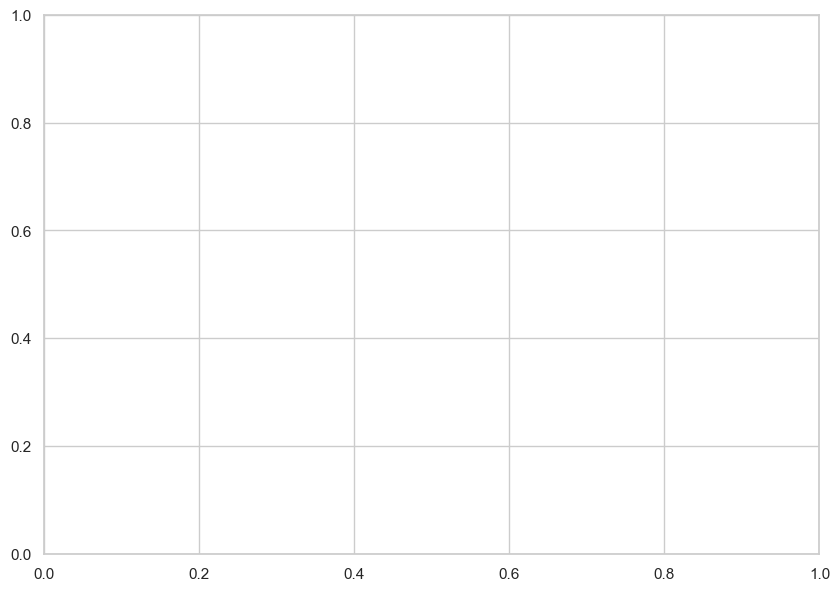

In [110]:
uber_df['MONTH'] = uber_df['MONTH'].map(dict)
plt.figure(figsize=(10,7))
sns.countplot(y=uber_df['MONTH'])
plt.show()

In [77]:
print(uber_df['MONTH'].head())
print(uber_df['MONTH'].unique())

0    Jan
1    Jan
2    Jan
3    Jan
4    Jan
Name: MONTH, dtype: object
['Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun' 'July' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec']


In [78]:
uber_df.groupby(['MONTH','PURPOSE'])['ROUND_TRIP'].count()

MONTH  PURPOSE        
Apr    Customer Visit      5
       Errand/Supplies     3
       Meal/Entertain      5
       Meeting             9
       NOT                 3
                          ..
Nov    Temporary Site      3
Oct    Meeting             1
       NOT                22
       Temporary Site      1
Sep    NOT                13
Name: ROUND_TRIP, Length: 64, dtype: int64

In [79]:
##CALCULATE THE MAINTUES TO COVER MILES?
uber_df['MINUTES']=uber_df['END_DATE'] -uber_df['START_DATE']

In [80]:
uber_df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,ROUND_TRIP,MONTH,MINUTES
1043,2016-12-12 13:22:00,2016-12-12 13:32:00,Business,Cary,Cary,3.1,Errand/Supplies,2016-12-12,13.0,Afternoon,yes,Dec,0 days 00:10:00
1044,2016-12-12 13:36:00,2016-12-12 13:51:00,Business,Cary,Apex,4.4,Meal/Entertain,2016-12-12,13.0,Afternoon,no,Dec,0 days 00:15:00
1045,2016-12-12 14:26:00,2016-12-12 14:39:00,Business,Apex,Cary,4.7,Customer Visit,2016-12-12,14.0,Afternoon,no,Dec,0 days 00:13:00
1046,2016-12-12 17:51:00,2016-12-12 18:01:00,Business,Cary,Morrisville,3.0,Meal/Entertain,2016-12-12,17.0,Evening,no,Dec,0 days 00:10:00
1047,2016-12-12 20:48:00,2016-12-12 20:57:00,Business,Morrisville,Cary,3.0,Customer Visit,2016-12-12,20.0,Night,no,Dec,0 days 00:09:00


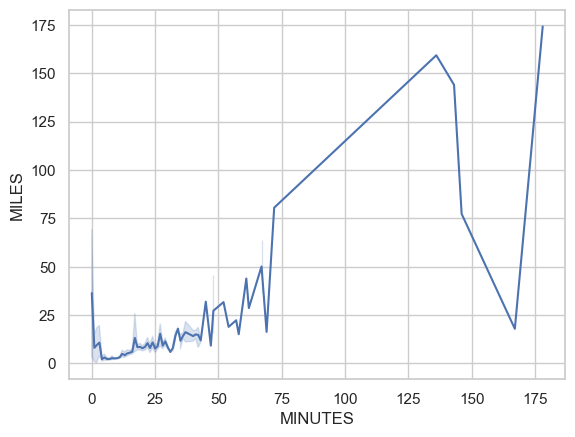

In [81]:
sns.lineplot(data=uber_df, x=uber_df['MINUTES'].dt.total_seconds()/60,y=uber_df['MILES'])
plt.show()

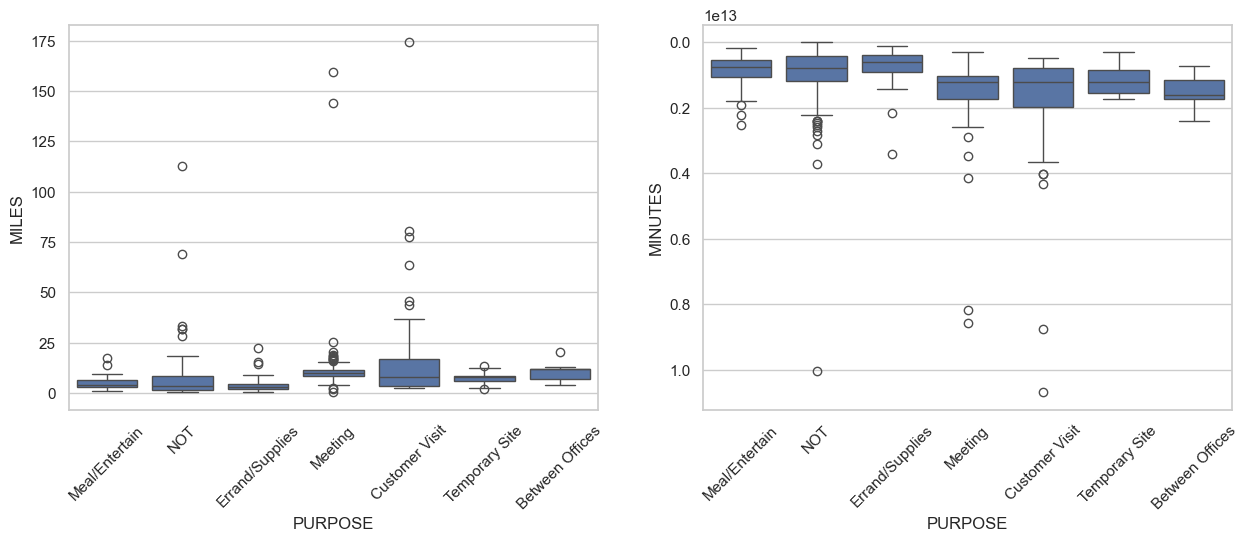

In [82]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=uber_df,x=uber_df['PURPOSE'],y=uber_df['MILES'])
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.boxplot(data=uber_df,x=uber_df['PURPOSE'],y=uber_df['MINUTES'])
plt.xticks(rotation=45)
plt.show()


In [83]:
## FOR EACH PURPOSE WHAT IS MINMIMUM MILES TRAVELLED , 
##MEAN MILES TRAVELLED AND WHAT IS MAXIMUM MILES TRAVELLED AND WHAT IS THE 
#MAXIMUM MILES TRAVELLED??
pd.DataFrame({'Min':uber_df.groupby(['PURPOSE'])['MILES'].min(),
              'Mean':uber_df.groupby(['PURPOSE'])['MILES'].mean(),
              'Max':uber_df.groupby(['PURPOSE'])['MILES'].max()})

,Min,Mean,Max
PURPOSE,,,
Between Offices,4.0,10.933333,20.5
Customer Visit,2.4,18.639130,174.2
Errand/Supplies,0.5,4.121277,22.3
Meal/Entertain,1.1,4.912500,17.3
Meeting,0.8,13.822222,159.3
NOT,0.6,7.073750,112.6
Temporary Site,1.9,7.757143,13.5


In [84]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,ROUND_TRIP,MONTH,MINUTES
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,yes,Jan,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning,yes,Jan,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,yes,Jan,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,yes,Jan,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon,no,Jan,0 days 01:07:00


In [85]:
##round trips for every purpose every month ?
pd.set_option('display.max_rows',None)##display all the rows 
uber_df.groupby(['MONTH','PURPOSE'])['ROUND_TRIP'].count()

MONTH  PURPOSE        
Apr    Customer Visit      5
       Errand/Supplies     3
       Meal/Entertain      5
       Meeting             9
       NOT                 3
Aug    Customer Visit      3
       Meal/Entertain      1
       Meeting             1
       NOT                38
Dec    Customer Visit     10
       Errand/Supplies    10
       Meal/Entertain     10
       Meeting             6
       NOT                 2
       Temporary Site      1
Feb    Between Offices     1
       Customer Visit      5
       Errand/Supplies     5
       Meal/Entertain     11
       Meeting             8
       NOT                 5
       Temporary Site      5
Jan    Customer Visit      3
       Errand/Supplies     4
       Meal/Entertain      6
       Meeting             8
       NOT                 1
       Temporary Site      1
July   Customer Visit      1
       Errand/Supplies     4
       Meal/Entertain      2
       Meeting            13
       NOT                19
       Temporary Sit

In [86]:
pd.set_option('display.max_colwidth',200)## it will display 200  characters  because df will not diplay fully 

In [87]:
pd.set_option('display.float_format','{:.2f}'.format)

In [88]:
data={f'Column_{i}':list(range(500)) for i in range(10)}
df=pd.DataFrame(data)
pd.set_option('display.large_repr','info')
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Column_0  500 non-null    int64
 1   Column_1  500 non-null    int64
 2   Column_2  500 non-null    int64
 3   Column_3  500 non-null    int64
 4   Column_4  500 non-null    int64
 5   Column_5  500 non-null    int64
 6   Column_6  500 non-null    int64
 7   Column_7  500 non-null    int64
 8   Column_8  500 non-null    int64
 9   Column_9  500 non-null    int64
dtypes: int64(10)
memory usage: 39.2 KB



In [89]:
data={f'Column_{i}':list(range(5)) for i in range(15)}
pd.DataFrame(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Column_0   5 non-null      int64
 1   Column_1   5 non-null      int64
 2   Column_2   5 non-null      int64
 3   Column_3   5 non-null      int64
 4   Column_4   5 non-null      int64
 5   Column_5   5 non-null      int64
 6   Column_6   5 non-null      int64
 7   Column_7   5 non-null      int64
 8   Column_8   5 non-null      int64
 9   Column_9   5 non-null      int64
 10  Column_10  5 non-null      int64
 11  Column_11  5 non-null      int64
 12  Column_12  5 non-null      int64
 13  Column_13  5 non-null      int64
 14  Column_14  5 non-null      int64
dtypes: int64(15)
memory usage: 732.0 bytes

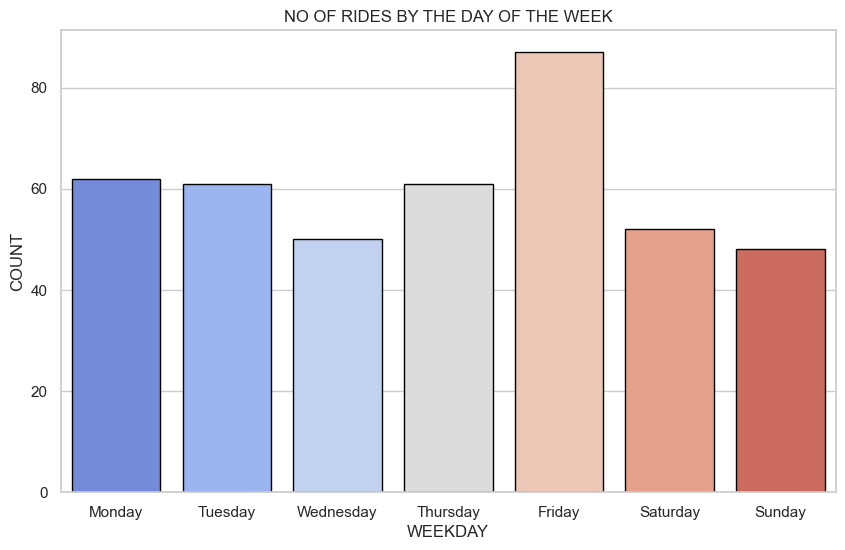

In [90]:
## are there more rides on weekdays or weekends 
uber_df['WEEKDAY']=uber_df['START_DATE'].dt.day_name()
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x=uber_df['WEEKDAY'], order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],palette='coolwarm',edgecolor='black')
plt.title('NO OF RIDES BY THE DAY OF THE WEEK')
plt.xlabel('WEEKDAY')
plt.ylabel('COUNT')
plt.show()

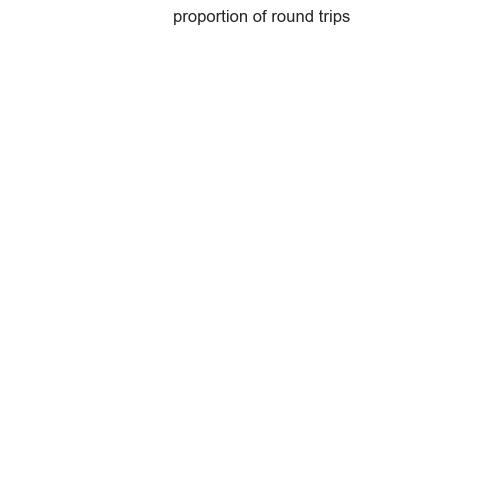

In [111]:
##how many rides were round trips??
round_trip_counts=uber_df['ROUND_TRIP'].value_counts()
plt.figure(figsize=(10,6))
round_trip_counts.plot(kind='pie',autopct='%1.1f%%', startangle=90,colormap='c')
plt.title('proportion of round trips')
plt.ylabel(' ')
plt.show()

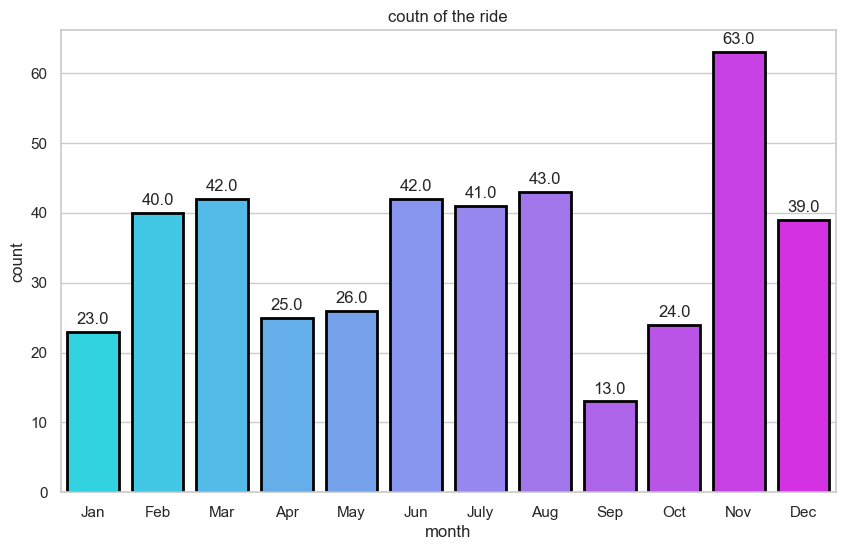

In [96]:
## how does the ride count changes acroos different months 
plt.figure(figsize=(10,6))
ax=sns.countplot(data=uber_df,x='MONTH',palette='cool',edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.title('coutn of the ride')
plt.xlabel('month')
plt.ylabel('count')
plt.show()



START
Cary                95
Morrisville         39
Whitebridge         34
Unknown Location    22
Durham              20
Raleigh             11
Westpark Place       8
Apex                 8
Berkeley             7
Kissimmee            6
Name: count, dtype: int64


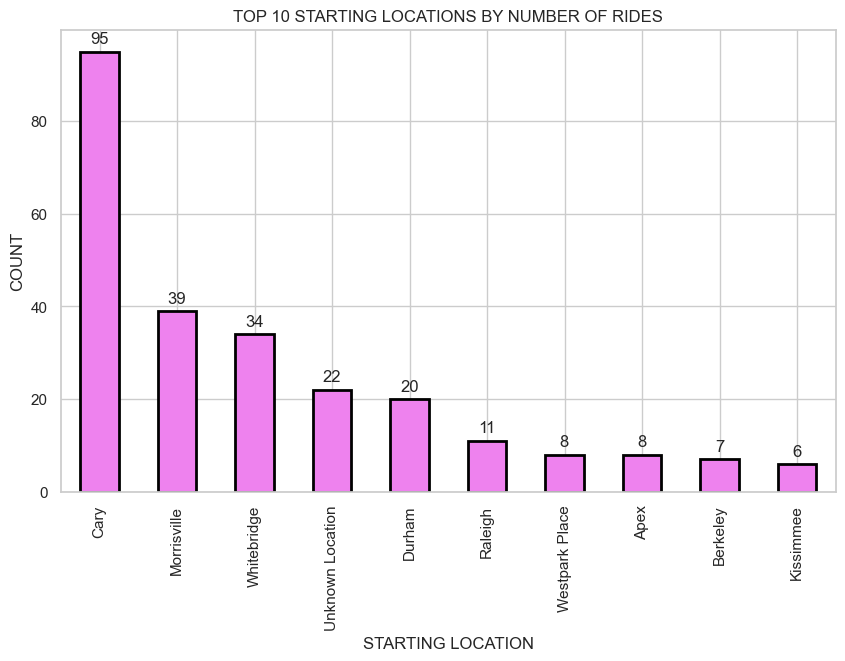

In [93]:
## which starting location (start) has the hightes number of the rides 
top_start_locations=uber_df['START'].value_counts().head(10)
print(top_start_locations)
plt.figure(figsize=(10,6))
ax=top_start_locations.plot(kind='bar',color='violet',edgecolor='black',linewidth=2)
plt.title('TOP 10 STARTING LOCATIONS BY NUMBER OF RIDES')
plt.xlabel('STARTING LOCATION')
plt.ylabel('COUNT')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.show()

STOP
Cary                96
Morrisville         41
Whitebridge         29
Unknown Location    21
Durham              19
Raleigh             11
Berkeley             8
Apex                 8
Edgehill Farms       7
Westpark Place       7
Name: count, dtype: int64


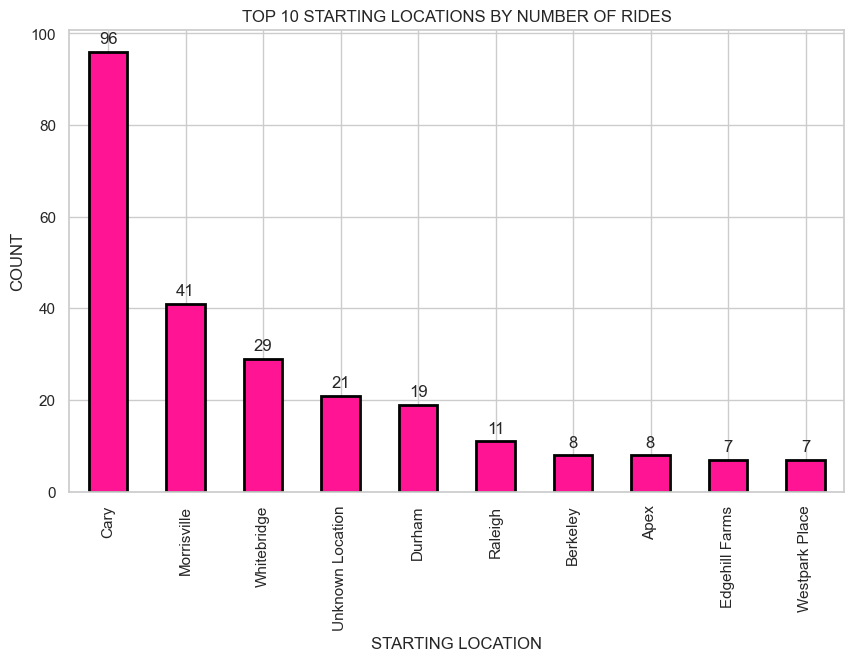

In [95]:
top_start_locations=uber_df['STOP'].value_counts().head(10)
print(top_start_locations)
plt.figure(figsize=(10,6))
ax=top_start_locations.plot(kind='bar',color='deeppink',edgecolor='black',linewidth=2)
plt.title('TOP 10 STARTING LOCATIONS BY NUMBER OF RIDES')
plt.xlabel('STARTING LOCATION')
plt.ylabel('COUNT')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.show()